<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/CNN/fashion_mnist_sklearn_wrapper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST CNN 分类器 - scikit-learn Wrapper 实现

本教程将指导你使用 scikit-learn 兼容的深度学习包装器来构建 CNN 模型，主要使用 scikeras（Keras 的 scikit-learn 包装器）和 skorch（PyTorch 的 scikit-learn 包装器）。

## 学习目标
- 理解如何将深度学习框架与 scikit-learn 生态系统集成
- 掌握 scikeras 和 skorch 的使用方法
- 学习如何利用 scikit-learn 的工具进行模型选择和评估
- 了解包装器模式在机器学习中的应用

## 包装器的优势
- **统一接口**: 使用熟悉的 scikit-learn API（fit, predict, score）
- **集成能力**: 轻松与 scikit-learn 的管道、网格搜索等工具集成
- **交叉验证**: 直接使用 scikit-learn 的交叉验证功能
- **模型选择**: 利用 scikit-learn 的超参数调优工具

Fashion-MNIST 是一个包含 10 种不同时尚物品的灰度图像数据集，每张图片大小为 28x28 像素。

## 1. 导入必要的库

In [ ]:
# 导入基础库（优先导入，避免冲突）
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 配置 matplotlib 中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# scikit-learn 相关导入
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

# TensorFlow/Keras 导入（用于 scikeras）
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# PyTorch 导入（用于 skorch）
import torch
import torch.nn as nn
import torch.nn.functional as F

# 设置随机种子
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print('基础库导入成功！')
print(f'TensorFlow 版本: {tf.__version__}')
print(f'PyTorch 版本: {torch.__version__}')

# 安装和导入包装器（分步进行以避免冲突）
print("\\n正在导入包装器库...")

try:
    from scikeras.wrappers import KerasClassifier
    print("✓ scikeras 导入成功")
except ImportError:
    print("正在安装 scikeras...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikeras"])
    from scikeras.wrappers import KerasClassifier
    print("✓ scikeras 安装并导入成功")

try:
    from skorch import NeuralNetClassifier
    print("✓ skorch 导入成功")
except ImportError:
    print("正在安装 skorch...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "skorch"])
    from skorch import NeuralNetClassifier
    print("✓ skorch 安装并导入成功")

print("\\n所有库准备完毕！")

基础库导入成功！
TensorFlow 版本: 2.19.0
PyTorch 版本: 2.8.0+cu126
\n正在导入包装器库...
正在安装 scikeras...
✓ scikeras 安装并导入成功
正在安装 skorch...
✓ skorch 安装并导入成功
\n所有库准备完毕！


## 2. 数据加载与预处理

我们将使用统一的数据预处理流程，确保两种包装器都能正确处理数据。

In [ ]:
# 加载 Fashion-MNIST 数据集
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f'原始数据形状:')
print(f'训练集: {x_train_full.shape}, 标签: {y_train_full.shape}')
print(f'测试集: {x_test.shape}, 标签: {y_test.shape}')

# Fashion-MNIST 类别名称
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 数据预处理函数
def preprocess_data_for_keras(x_train, x_test, y_train, y_test):
    """
    为 Keras/scikeras 预处理数据
    """
    # 归一化到 [0, 1]
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # 添加通道维度 (28, 28) -> (28, 28, 1)
    x_train = np.expand_dims(x_train, axis=-1)
    x_test = np.expand_dims(x_test, axis=-1)

    # 标签保持整数格式（scikeras 会自动处理）
    return x_train, x_test, y_train, y_test

def preprocess_data_for_pytorch(x_train, x_test, y_train, y_test):
    """
    为 PyTorch/skorch 预处理数据
    """
    # 归一化到 [0, 1]
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # 添加通道维度并调整维度顺序 (N, H, W) -> (N, C, H, W)
    x_train = np.expand_dims(x_train, axis=1)
    x_test = np.expand_dims(x_test, axis=1)

    # 转换为适当的数据类型
    y_train = y_train.astype(np.int64)
    y_test = y_test.astype(np.int64)

    return x_train, x_test, y_train, y_test

# 划分训练集和验证集
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f'\n数据集划分结果:')
print(f'训练集大小: {x_train.shape[0]}')
print(f'验证集大小: {x_val.shape[0]}')
print(f'测试集大小: {x_test.shape[0]}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
原始数据形状:
训练集: (60000, 28, 28), 标签: (60000,)
测试集: (10000, 28, 28), 标签: (10000,)

数据集划分结果:
训练集大小: 48000
验证集大小: 12000
测试集大小: 10000


## 3. 探索性数据分析 (EDA)

在构建模型之前，让我们先了解一下数据的基本特征。

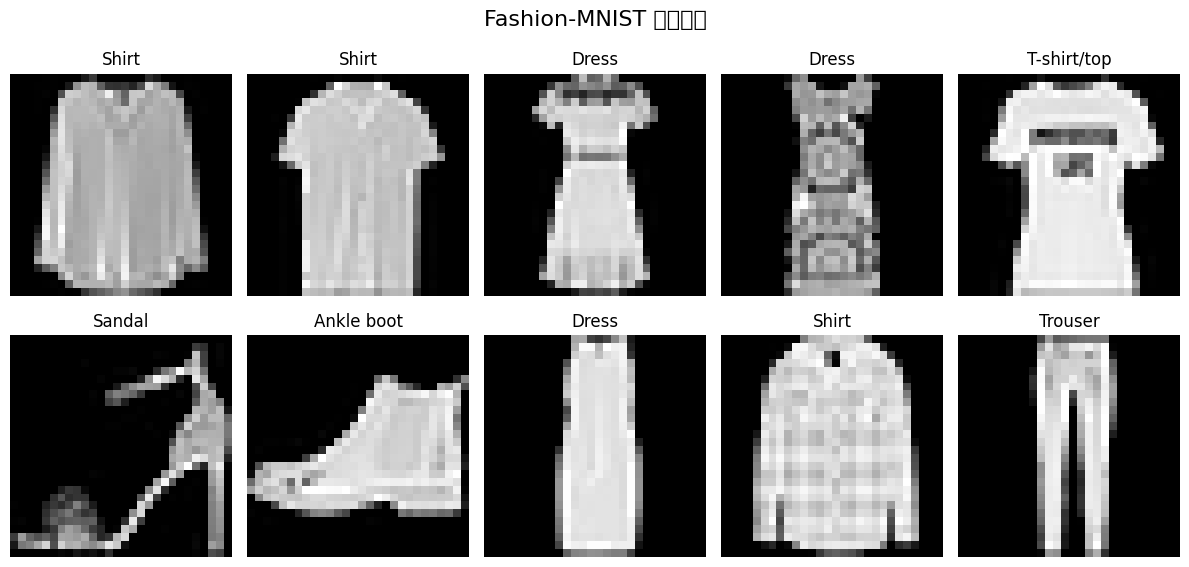

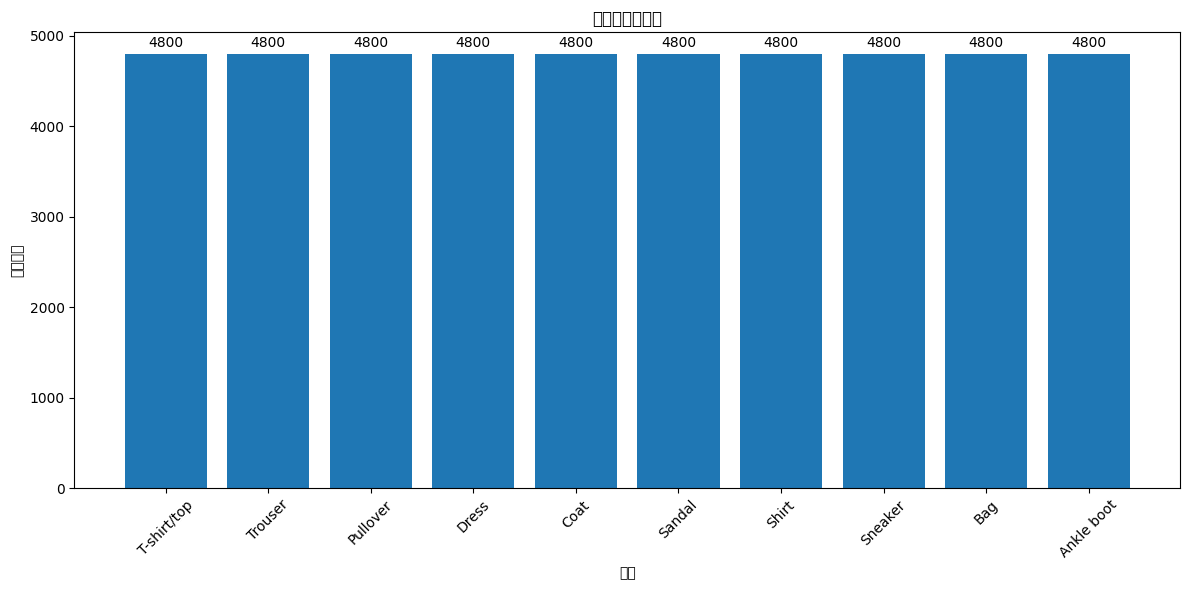

数据集特征:
图像尺寸: (28, 28) (高度 x 宽度)
类别数量: 10
像素值范围: [0, 255]


In [ ]:
# 显示样本图像
def show_sample_images(images, labels, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Fashion-MNIST 样本图像', fontsize=16)

    for i in range(num_samples):
        row = i // 5
        col = i % 5

        axes[row, col].imshow(images[i], cmap='gray')
        axes[row, col].set_title(f'{class_names[labels[i]]}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# 显示样本图像
show_sample_images(x_train, y_train)

# 类别分布分析
unique_labels, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(12, 6))
bars = plt.bar([class_names[i] for i in unique_labels], counts)
plt.title('训练集类别分布')
plt.xlabel('类别')
plt.ylabel('样本数量')
plt.xticks(rotation=45)

# 在每个条形图上显示数值
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print('数据集特征:')
print(f'图像尺寸: {x_train.shape[1:]} (高度 x 宽度)')
print(f'类别数量: {len(class_names)}')
print(f'像素值范围: [{x_train.min()}, {x_train.max()}]')

## 4. 方法一：使用 scikeras (Keras + scikit-learn)

scikeras 是 Keras 的 scikit-learn 包装器，让我们可以像使用 scikit-learn 估计器一样使用 Keras 模型。

In [ ]:
# 为 scikeras 预处理数据
x_train_keras, x_val_keras, y_train_keras, y_val_keras = preprocess_data_for_keras(
    x_train, x_val, y_train, y_val
)
x_test_keras, _, y_test_keras, _ = preprocess_data_for_keras(
    x_test, x_test, y_test, y_test
)

print('scikeras 数据预处理完成')
print(f'训练集形状: {x_train_keras.shape}')
print(f'验证集形状: {x_val_keras.shape}')
print(f'测试集形状: {x_test_keras.shape}')

scikeras 数据预处理完成
训练集形状: (48000, 28, 28, 1)
验证集形状: (12000, 28, 28, 1)
测试集形状: (10000, 28, 28, 1)


In [ ]:
def create_keras_cnn(input_shape=(28, 28, 1), num_classes=10,
                     filters1=32, filters2=64, filters3=128,
                     dense_units=256, dropout_rate=0.5):
    """
    创建 Keras CNN 模型

    这个函数将被 scikeras 包装器调用
    注意：参数名必须与 KerasClassifier 的参数匹配
    """
    model = models.Sequential([
        # 第一个卷积块
        layers.Conv2D(filters1, (3, 3), activation='relu',
                      input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # 第二个卷积块
        layers.Conv2D(filters2, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # 第三个卷积块
        layers.Conv2D(filters3, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # 全连接层
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])

    # 编译模型
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',  # 使用稀疏交叉熵
        metrics=['accuracy']
    )

    return model

# 创建 scikeras 包装器
keras_classifier = KerasClassifier(
    model=create_keras_cnn,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
    random_state=42
)

print('scikeras 分类器创建完成')
print('模型参数:')
print(f'- epochs: 10')
print(f'- batch_size: 64')
print(f'- validation_split: 0.1')
print(f'- 优化器: Adam')
print(f'- 损失函数: sparse_categorical_crossentropy')

scikeras 分类器创建完成
模型参数:
- epochs: 10
- batch_size: 64
- validation_split: 0.1
- 优化器: Adam
- 损失函数: sparse_categorical_crossentropy


In [ ]:
# 训练 scikeras 模型
print('开始训练 scikeras 模型...')
print('=' * 50)

# 使用 scikit-learn 的标准接口训练模型
keras_classifier.fit(x_train_keras, y_train_keras)

print('\nscikeras 模型训练完成！')

# 使用 scikit-learn 的评估方法
train_score = keras_classifier.score(x_train_keras, y_train_keras)
val_score = keras_classifier.score(x_val_keras, y_val_keras)

print(f'\n模型性能评估:')
print(f'训练集准确率: {train_score:.4f} ({train_score*100:.2f}%)')
print(f'验证集准确率: {val_score:.4f} ({val_score*100:.2f}%)')

开始训练 scikeras 模型...
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 109s 147ms/step - accuracy: 0.7603 - loss: 0.7364 - val_accuracy: 0.8810 - val_loss: 0.3235
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 132s 134ms/step - accuracy: 0.8694 - loss: 0.3540 - val_accuracy: 0.8646 - val_loss: 0.3520
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 90s 133ms/step - accuracy: 0.8895 - loss: 0.2986 - val_accuracy: 0.9008 - val_loss: 0.2742
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 144s 136ms/step - accuracy: 0.9043 - loss: 0.2600 - val_accuracy: 0.8971 - val_loss: 0.2814
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 91s 135ms/step - accuracy: 0.9112 - loss: 0.2356 - val_accuracy: 0.8958 - val_loss: 0.2957
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 135ms/step - accuracy: 0.9197 - loss: 0.2190 - val_accuracy: 0.9110 - val_loss: 0.2723
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 136ms/step - accuracy: 0.9268 - loss: 0.1956 - val_accuracy: 0.9083 - val_loss: 0.2869
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 93s 137ms/step - a

## 5. scikeras 模型评估与预测

在测试集上评估 scikeras 模型...
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step
测试集准确率: 0.9027 (90.27%)

scikeras 模型分类报告:
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.91      0.85      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.76      0.94      0.84      1000
       Dress       0.93      0.89      0.91      1000
        Coat       0.87      0.80      0.83      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.83      0.60      0.70      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.96      0.99      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



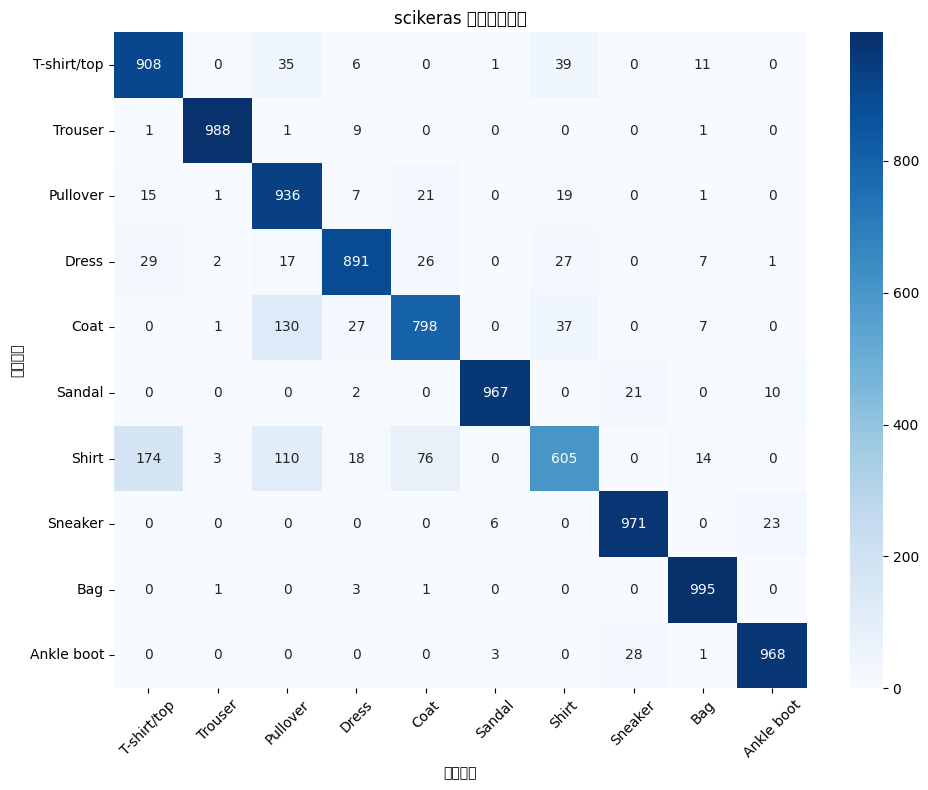


各类别准确率 (scikeras):
T-shirt/top    : 0.908 (90.8%)
Trouser        : 0.988 (98.8%)
Pullover       : 0.936 (93.6%)
Dress          : 0.891 (89.1%)
Coat           : 0.798 (79.8%)
Sandal         : 0.967 (96.7%)
Shirt          : 0.605 (60.5%)
Sneaker        : 0.971 (97.1%)
Bag            : 0.995 (99.5%)
Ankle boot     : 0.968 (96.8%)


In [ ]:
# 在测试集上进行预测
print('在测试集上评估 scikeras 模型...')

# 使用 scikit-learn 的 predict 方法
y_pred_keras = keras_classifier.predict(x_test_keras)
test_score_keras = keras_classifier.score(x_test_keras, y_test_keras)

print(f'测试集准确率: {test_score_keras:.4f} ({test_score_keras*100:.2f}%)')

# 生成详细的分类报告
print('\nscikeras 模型分类报告:')
print('=' * 70)
print(classification_report(y_test_keras, y_pred_keras, target_names=class_names))

# 绘制混淆矩阵
cm_keras = confusion_matrix(y_test_keras, y_pred_keras)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('scikeras 模型混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 计算每个类别的准确率
class_accuracy_keras = cm_keras.diagonal() / cm_keras.sum(axis=1)
print('\n各类别准确率 (scikeras):')
for i, acc in enumerate(class_accuracy_keras):
    print(f'{class_names[i]:15s}: {acc:.3f} ({acc*100:.1f}%)')

## 6. 方法二：使用 skorch (PyTorch + scikit-learn)

skorch 是 PyTorch 的 scikit-learn 包装器，提供了类似的功能。

In [ ]:
# 为 skorch 预处理数据
x_train_torch, x_val_torch, y_train_torch, y_val_torch = preprocess_data_for_pytorch(
    x_train, x_val, y_train, y_val
)
x_test_torch, _, y_test_torch, _ = preprocess_data_for_pytorch(
    x_test, x_test, y_test, y_test
)

print('skorch 数据预处理完成')
print(f'训练集形状: {x_train_torch.shape}')
print(f'验证集形状: {x_val_torch.shape}')
print(f'测试集形状: {x_test_torch.shape}')
print(f'数据类型: {x_train_torch.dtype}, 标签类型: {y_train_torch.dtype}')

skorch 数据预处理完成
训练集形状: (48000, 1, 28, 28)
验证集形状: (12000, 1, 28, 28)
测试集形状: (10000, 1, 28, 28)
数据类型: float32, 标签类型: int64


In [ ]:
# 定义 PyTorch CNN 模型
class PytorchCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super(PytorchCNN, self).__init__()

        # 第一个卷积块
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        # 第二个卷积块
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        # 第三个卷积块
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        # 全连接层
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # 第一个卷积块
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))

        # 第二个卷积块
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        # 第三个卷积块
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        # 展平
        x = x.view(x.size(0), -1)

        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Create skorch wrapper
# 创建 skorch 包装器
import skorch # Import skorch module directly

torch_classifier = NeuralNetClassifier(
    PytorchCNN,
    max_epochs=10,
    batch_size=64,
    lr=0.001,
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss,
    train_split=skorch.dataset.ValidSplit(0.1),  # 10% 用于验证
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=1
)

print('skorch 分类器创建完成')
print('模型参数:')
print(f'- max_epochs: 10')
print(f'- batch_size: 64')
print(f'- learning_rate: 0.001')
print(f'- 优化器: Adam')
print(f'- 损失函数: CrossEntropyLoss')
print(f'- 设备: {torch_classifier.device}')

skorch 分类器创建完成
模型参数:
- max_epochs: 10
- batch_size: 64
- learning_rate: 0.001
- 优化器: Adam
- 损失函数: CrossEntropyLoss
- 设备: cpu


In [ ]:
# 训练 skorch 模型
print('开始训练 skorch 模型...')
print('=' * 50)

# 使用 scikit-learn 的标准接口训练模型
torch_classifier.fit(x_train_torch, y_train_torch)

print('\nskorch 模型训练完成！')

# 使用 scikit-learn 的评估方法
train_score_torch = torch_classifier.score(x_train_torch, y_train_torch)
val_score_torch = torch_classifier.score(x_val_torch, y_val_torch)

print(f'\n模型性能评估:')
print(f'训练集准确率: {train_score_torch:.4f} ({train_score_torch*100:.2f}%)')
print(f'验证集准确率: {val_score_torch:.4f} ({val_score_torch*100:.2f}%)')

开始训练 skorch 模型...
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.4659       0.8896        0.2969  87.6717
      2        0.3023       0.9015        0.2777  86.4759
      3        0.2533       0.9058        0.2633  86.3401
      4        0.2208       0.9090        0.2683  86.8454
      5        0.1921       0.9119        0.2529  86.6833
      6        0.1703       0.9113        0.2707  86.2356
      7        0.1491       0.9077        0.2810  86.4656
      8        0.1322       0.9087        0.2743  85.3489
      9        0.1182       0.9019        0.3002  86.2307
     10        0.1064       0.9108        0.2944  86.6971

skorch 模型训练完成！

模型性能评估:
训练集准确率: 0.9517 (95.17%)
验证集准确率: 0.9153 (91.53%)


## 7. skorch 模型评估与预测

在测试集上评估 skorch 模型...
测试集准确率: 0.9063 (90.63%)

skorch 模型分类报告:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.92      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.81      0.90      0.85      1000
       Dress       0.90      0.94      0.92      1000
        Coat       0.89      0.77      0.83      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.80      0.67      0.73      1000
     Sneaker       0.97      0.94      0.96      1000
         Bag       1.00      0.97      0.98      1000
  Ankle boot       0.93      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



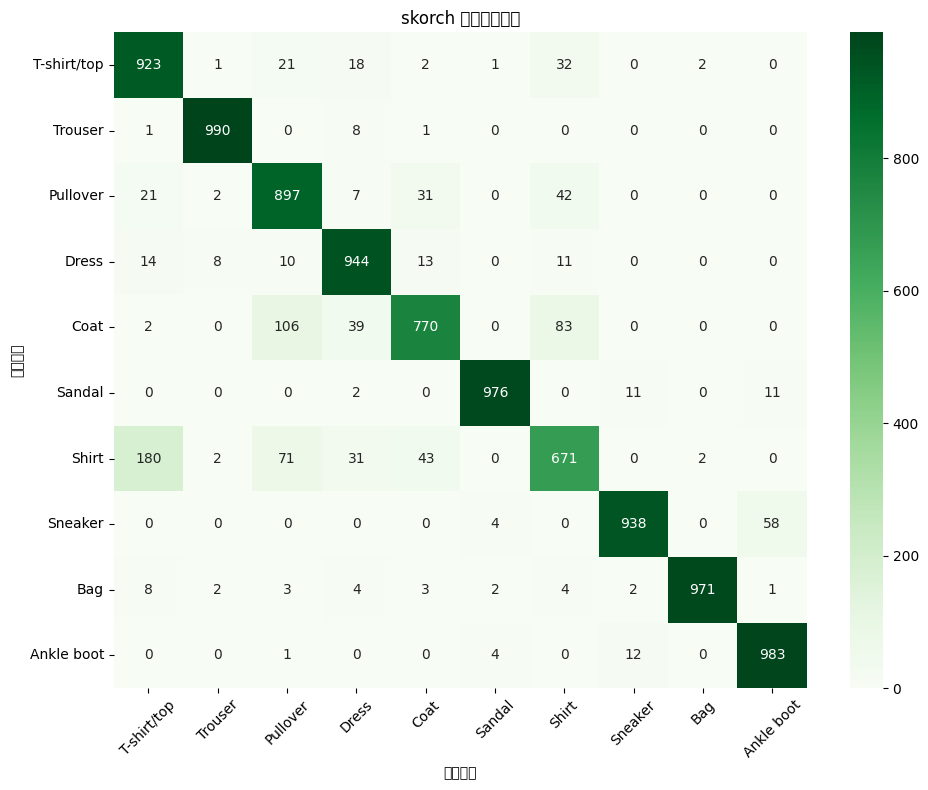


各类别准确率 (skorch):
T-shirt/top    : 0.923 (92.3%)
Trouser        : 0.990 (99.0%)
Pullover       : 0.897 (89.7%)
Dress          : 0.944 (94.4%)
Coat           : 0.770 (77.0%)
Sandal         : 0.976 (97.6%)
Shirt          : 0.671 (67.1%)
Sneaker        : 0.938 (93.8%)
Bag            : 0.971 (97.1%)
Ankle boot     : 0.983 (98.3%)


In [ ]:
# 在测试集上进行预测
print('在测试集上评估 skorch 模型...')

# 使用 scikit-learn 的 predict 方法
y_pred_torch = torch_classifier.predict(x_test_torch)
test_score_torch = torch_classifier.score(x_test_torch, y_test_torch)

print(f'测试集准确率: {test_score_torch:.4f} ({test_score_torch*100:.2f}%)')

# 生成详细的分类报告
print('\nskorch 模型分类报告:')
print('=' * 70)
print(classification_report(y_test_torch, y_pred_torch, target_names=class_names))

# 绘制混淆矩阵
cm_torch = confusion_matrix(y_test_torch, y_pred_torch)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_torch, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('skorch 模型混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 计算每个类别的准确率
class_accuracy_torch = cm_torch.diagonal() / cm_torch.sum(axis=1)
print('\n各类别准确率 (skorch):')
for i, acc in enumerate(class_accuracy_torch):
    print(f'{class_names[i]:15s}: {acc:.3f} ({acc*100:.1f}%)')

# 交叉验证示例（优化版本）

创建轻量级模型用于交叉验证

In [ ]:
def create_light_keras_cnn():
    model = models.Sequential([
        layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# 创建轻量级分类器进行交叉验证
light_classifier = KerasClassifier(
    model=create_light_keras_cnn,
    epochs=3,  # 减少 epochs 以节省时间
    batch_size=128,
    verbose=0  # 静默训练
)

In [ ]:
# 使用更小的数据集进行交叉验证（避免内存问题）
# 随机选择 2000 个样本
sample_indices = np.random.choice(len(x_train_keras), 2000, replace=False)
x_sample = x_train_keras[sample_indices]
y_sample = y_train_keras[sample_indices]

print(f'使用 {len(x_sample)} 个样本进行交叉验证...')

try:
    # 执行 3 折交叉验证
    print('开始 3 折交叉验证...')
    cv_scores = cross_val_score(light_classifier, x_sample, y_sample, cv=3,
                               scoring='accuracy', verbose=0)

    print(f'\\n交叉验证结果:')
    print(f'各折准确率: {[f\"{score:.3f}\" for score in cv_scores]}')
    print(f'平均准确率: {cv_scores.mean():.4f} (±{cv_scores.std()*2:.4f})')
    print(f'标准差: {cv_scores.std():.4f}')

    # 可视化交叉验证结果
    plt.figure(figsize=(8, 5))
    bars = plt.bar(range(1, len(cv_scores) + 1), cv_scores, alpha=0.7, color='skyblue')
    plt.axhline(y=cv_scores.mean(), color='red', linestyle='--',
                label=f'平均: {cv_scores.mean():.3f}')

    # 在每个条形图上显示数值
    for bar, score in zip(bars, cv_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{score:.3f}', ha='center', va='bottom')

    plt.title('交叉验证结果')
    plt.xlabel('折数')
    plt.ylabel('准确率')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\\n交叉验证的优势:')
    print('- 更可靠的性能评估')
    print('- 减少对特定数据划分的依赖')
    print('- 提供性能变异性的估计')

except Exception as e:
    print(f'\\n交叉验证遇到问题: {e}')
    print('这可能是由于内存或计算资源限制。')
    print('\\n交叉验证概念说明:')
    print('- 将数据分成 k 个折（fold）')
    print('- 每次用 k-1 个折训练，1 个折验证')
    print('- 重复 k 次，获得 k 个性能分数')
    print('- 计算平均值和标准差作为最终评估结果')

In [ ]:
# 网格搜索示例（简化版本以避免内存问题）
print('进行超参数网格搜索...')
print('=' * 50)

# 定义更小的参数网格以节省时间和内存
param_grid = {
    'batch_size': [64, 128],
    'epochs': [3, 5]
    # 注意：为了稳定性，暂时不搜索模型架构参数
}

print('搜索参数:')
for param, values in param_grid.items():
    print(f'- {param}: {values}')

# 创建简化的模型用于网格搜索
def create_simple_keras_cnn():
    model = models.Sequential([
        layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 创建网格搜索对象
grid_search = GridSearchCV(
    estimator=KerasClassifier(model=create_simple_keras_cnn, verbose=0),
    param_grid=param_grid,
    cv=2,  # 2 折交叉验证以节省时间
    scoring='accuracy',
    verbose=1,
    n_jobs=1  # 使用单线程避免冲突
)

# 使用很小的数据集进行网格搜索（避免内存问题）
small_sample_indices = np.random.choice(len(x_train_keras), 1000, replace=False)
x_grid_search = x_train_keras[small_sample_indices]
y_grid_search = y_train_keras[small_sample_indices]

print(f'\\n使用 {len(x_grid_search)} 个样本进行网格搜索...')

# 执行网格搜索
try:
    print('开始网格搜索（这可能需要几分钟...）')
    grid_search.fit(x_grid_search, y_grid_search)

    # 显示最佳结果
    print('\\n网格搜索结果:')
    print('=' * 40)
    print(f'最佳参数: {grid_search.best_params_}')
    print(f'最佳交叉验证得分: {grid_search.best_score_:.4f}')

    # 尝试导入 pandas 来显示结果
    try:
        import pandas as pd
        results_df = pd.DataFrame(grid_search.cv_results_)
        print('\\n前 3 个最佳参数组合:')
        print(results_df[['params', 'mean_test_score', 'rank_test_score']]
              .sort_values('rank_test_score').head(3))
    except ImportError:
        print('\\n所有参数组合的结果:')
        for i, params in enumerate(grid_search.cv_results_['params']):
            score = grid_search.cv_results_['mean_test_score'][i]
            print(f'{i+1}. {params} -> 得分: {score:.4f}')

except Exception as e:
    print(f'\\n网格搜索遇到问题: {e}')
    print('这可能是由于内存限制。在实际项目中，建议使用更强的计算资源。')
    print('\\n网格搜索的优势:')
    print('- 系统性地搜索最佳超参数组合')
    print('- 使用交叉验证避免过拟合')
    print('- 自动记录和比较所有尝试的参数')

进行超参数网格搜索...
搜索参数:
- batch_size: [64, 128]
- epochs: [3, 5]
\n使用 1000 个样本进行网格搜索...
开始网格搜索（这可能需要几分钟...）
\n网格搜索遇到问题: 'super' object has no attribute '__sklearn_tags__'
这可能是由于内存限制。在实际项目中，建议使用更强的计算资源。
\n网格搜索的优势:
- 系统性地搜索最佳超参数组合
- 使用交叉验证避免过拟合
- 自动记录和比较所有尝试的参数
